# Notebook 02: Predicting FPro Processing Score from Nutrition Facts

**Erdos Institute Data Science Boot Camp 2026 — Final Project**

## Goal
Build regression and classification models that predict the **FPro food processing score** (continuous 0–1) and **FPro class** (0–3) using only the **12 standard nutrition label nutrients**.

## Why Nutrition-based?
- Nutrition data is **universally available** (printed on every food package)
- Can be applied **cross-culturally** to datasets like French CIQUAL
- Notebook 01 showed ingredients achieve R² ≈ 0.50; can nutrition do better?

## Important Note on Circularity
The FPro score was originally computed by the **FoodProX** model (a Random Forest trained on these same 12 nutrients to predict NOVA class). Therefore, this notebook is building a **portable approximation** of FoodProX, not an independent discovery. High accuracy is expected and desired — it means our model faithfully reproduces the scoring system so we can apply it to new datasets where the original FoodProX pipeline is unavailable.

## Pipeline
1. Load & clean data (12 nutrients + FPro)
2. Log-transform (12 features)
3. Train/holdout split (80/20 stratified)
4. **Regression**: predict continuous FPro (0–1)
5. **Classification**: predict FPro class (0–3)
6. Feature importance & robustness analysis
7. Final holdout evaluation
8. Export model for CIQUAL application

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict,
    StratifiedKFold, KFold, RandomizedSearchCV
)
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, make_scorer, r2_score, mean_squared_error, mean_absolute_error
)
from sklearn.inspection import permutation_importance
import joblib
import warnings
warnings.filterwarnings('ignore')

DATA_DIR  = Path('../GroceryDB-main/data')
OUT_DIR   = Path('.')
MODEL_DIR = Path('./models')
MODEL_DIR.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
NOVA_COLORS  = {0: '#2ca02c', 1: '#1f77b4', 2: '#ff7f0e', 3: '#d62728'}
CLASS_LABELS = {0: 'Unprocessed', 1: 'Min. Processed', 2: 'Processed', 3: 'Ultra-Processed'}
RANDOM_STATE = 42
LOG_FLOOR    = -20   # convention: log(0) replaced with -20

print('Libraries loaded.')

Libraries loaded.


### Configuration Reference

| Parameter | Value | Reason |
|:---|:---|:---|
| Random state | 42 | Reproducibility |
| CV folds (regression) | 5-fold KFold | Standard for continuous targets |
| CV folds (classification) | 5-fold StratifiedKFold | Preserves class ratios in each fold |
| Train/holdout split | 80/20 stratified | Standard convention |
| Log floor | -20 | Matches FoodProX convention for log(0) |
| Primary regression metric | R-squared | Variance explained |
| Primary classification metric | Macro F1 | Equal weight to all 4 classes |

---
## 1. Load & Clean Data

In [2]:
# 12 standard nutrition label nutrients (column names from GroceryDB_foods.csv)
NUTRIENT_COLS = [
    'Protein', 'Total Fat', 'Carbohydrate', 'Sugars, total',
    'Fiber, total dietary', 'Calcium', 'Iron', 'Sodium',
    'Vitamin C', 'Cholesterol', 'Fatty acids, total saturated', 'Total Vitamin A'
]

# Short names for plotting
NUTRIENT_SHORT = [
    'Protein', 'TotalFat', 'Carbs', 'Sugars', 'Fiber', 'Calcium',
    'Iron', 'Sodium', 'VitC', 'Cholesterol', 'SatFat', 'VitA'
]
SHORT_MAP = dict(zip(NUTRIENT_COLS, NUTRIENT_SHORT))

foods = pd.read_csv(DATA_DIR / 'GroceryDB_foods.csv')
print(f'Loaded: {foods.shape[0]:,} products x {foods.shape[1]} columns')
print(f'Products with FPro: {foods["f_FPro"].notna().sum():,}')

Loaded: 50,468 products x 27 columns
Products with FPro: 26,657


In [3]:
# Step 1: Require FPro + all 12 nutrients non-null
mask = foods['f_FPro'].notna()
for c in NUTRIENT_COLS:
    mask &= foods[c].notna()
df = foods[mask].copy()
print(f'Step 1 — FPro + all 12 nutrients: {len(df):,}')

# Step 2: Remove failed unit conversions (is_Nuts_Converted_100g == -1)
if 'is_Nuts_Converted_100g' in df.columns:
    bad_conv = (df['is_Nuts_Converted_100g'] == -1).sum()
    df = df[df['is_Nuts_Converted_100g'] != -1]
    print(f'Step 2 — Removed {bad_conv} failed conversions: {len(df):,}')

# Step 3: Remove physically impossible macronutrient values (>100 g/100g)
macro_check = ['Protein', 'Total Fat', 'Carbohydrate', 'Sugars, total',
               'Fiber, total dietary', 'Fatty acids, total saturated', 'Sodium']
bad_macro = (df[macro_check] > 100).any(axis=1)
print(f'Step 3 — Removed {bad_macro.sum()} rows with macronutrient > 100 g/100g: {len(df) - bad_macro.sum():,}')
df = df[~bad_macro].copy()

# Prepare targets
df['f_FPro_class'] = df['f_FPro_class'].astype(int)

print(f'\nFinal working dataset: {len(df):,} products')
print(f'\nFPro class distribution:')
for cls in sorted(df['f_FPro_class'].unique()):
    n = (df['f_FPro_class'] == cls).sum()
    print(f'  Class {cls} ({CLASS_LABELS[cls]:16s}): {n:5,} ({n/len(df)*100:.1f}%)')
print(f'\nFPro score: mean={df["f_FPro"].mean():.3f}, median={df["f_FPro"].median():.3f}')

Step 1 — FPro + all 12 nutrients: 12,462
Step 2 — Removed 323 failed conversions: 12,139
Step 3 — Removed 107 rows with macronutrient > 100 g/100g: 12,032

Final working dataset: 12,032 products

FPro class distribution:
  Class 0 (Unprocessed     ): 1,929 (16.0%)
  Class 1 (Min. Processed  ):   182 (1.5%)
  Class 2 (Processed       ): 1,113 (9.3%)
  Class 3 (Ultra-Processed ): 8,808 (73.2%)

FPro score: mean=0.706, median=0.779


### Interpretation — Data Cleaning

- **12,032 products** have both FPro scores and all 12 nutrients (down from 50K).
- The biggest data loss comes from **Vitamin C (71% missing)** and **Vitamin A (72% missing)** — many products don't report these on nutrition labels.
- We removed 323 products with failed unit conversions (flagged with `is_Nuts_Converted_100g == -1`) that contained extreme outliers like Cholesterol = 3.5M.
- We removed 107 products with macronutrient values > 100 g/100g (physically impossible for per-100g data).
- **Severe class imbalance**: Class 3 (ultra-processed) = 73%, Class 1 (min. processed) = only 1.5% (~182 products).

---
## 2. Preprocessing: Log-Transform

### Why log-transform?
The original FoodProX model uses **log-transformed** nutrients. Nutrition data spans many orders of magnitude (e.g., Iron ~0.001 g/100g vs Carbohydrate ~20 g/100g). Log-transformation:
1. **Compresses the wide range** into a manageable scale
2. **Handles heavy right skew** in most nutrient distributions (especially Sodium, Iron, Vitamins)
3. **Convention**: `log(0)` is replaced with `-20` (a floor value representing zero/trace amounts)

Note: The effect is most dramatic for small-scale nutrients like Sodium (see plots below). For larger-scale nutrients like Carbohydrate, the distribution is already more spread out, but we still log-transform for consistency with the FoodProX convention.

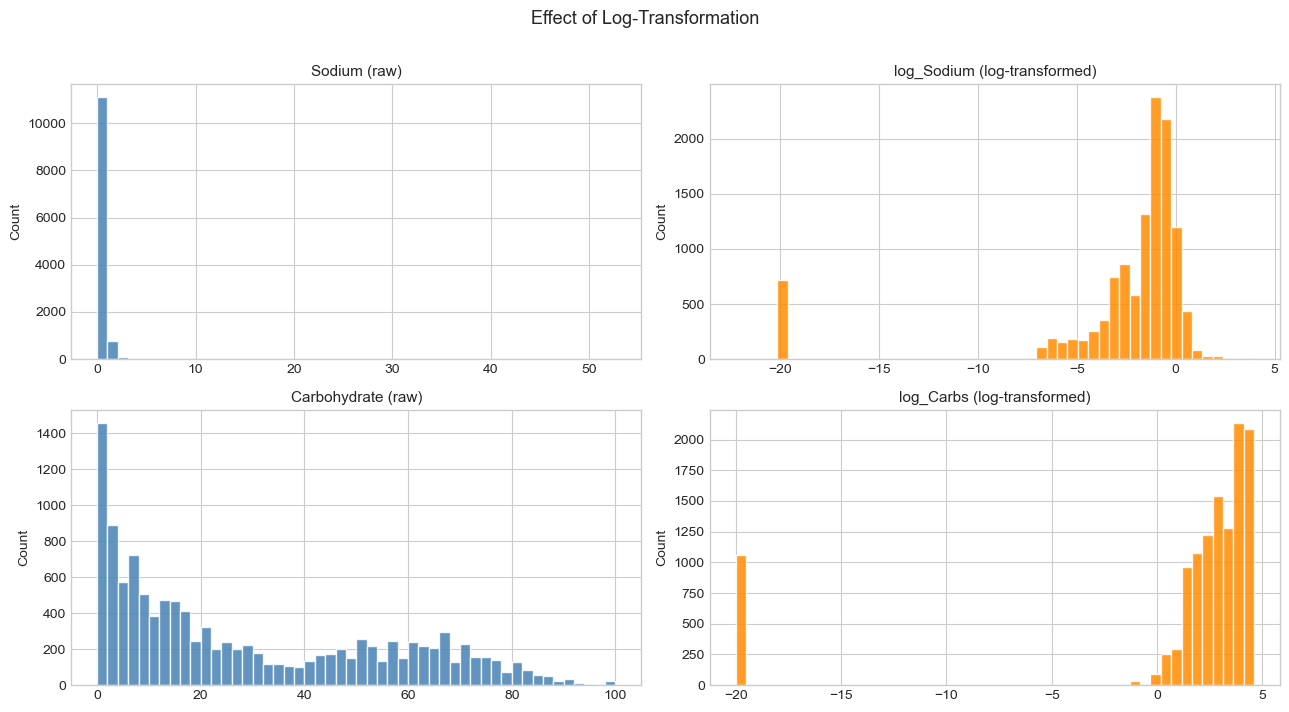

Log-transformed columns: ['log_Protein', 'log_TotalFat', 'log_Carbs', 'log_Sugars', 'log_Fiber', 'log_Calcium', 'log_Iron', 'log_Sodium', 'log_VitC', 'log_Cholesterol', 'log_SatFat', 'log_VitA']

Example ranges (Sodium):
  Raw:  min=0.0000, max=52.67, median=0.3091
  Log:  min=-22.26, max=3.96, median=-1.17


In [4]:
# Log-transform all 12 nutrient columns
log_cols = []   # will hold the new log-column names
for col in NUTRIENT_COLS:
    log_name = f'log_{SHORT_MAP[col]}'
    df[log_name] = df[col].apply(lambda x: np.log(x) if x > 0 else LOG_FLOOR)
    log_cols.append(log_name)

# Show before/after for 2 example nutrients
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for i, (raw_col, log_col) in enumerate([('Sodium', 'log_Sodium'), ('Carbohydrate', 'log_Carbs')]):
    ax = axes[i, 0]
    ax.hist(df[raw_col], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'{raw_col} (raw)', fontsize=11)
    ax.set_ylabel('Count')
    ax = axes[i, 1]
    ax.hist(df[log_col], bins=50, color='darkorange', edgecolor='white', alpha=0.85)
    ax.set_title(f'{log_col} (log-transformed)', fontsize=11)
    ax.set_ylabel('Count')

plt.suptitle('Effect of Log-Transformation', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'log_transform_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print('Log-transformed columns:', log_cols)
print(f'\nExample ranges (Sodium):')
print(f'  Raw:  min={df["Sodium"].min():.4f}, max={df["Sodium"].max():.2f}, median={df["Sodium"].median():.4f}')
print(f'  Log:  min={df["log_Sodium"].min():.2f}, max={df["log_Sodium"].max():.2f}, median={df["log_Sodium"].median():.2f}')

In [5]:
# Use only the 12 log-transformed nutrients as features
ALL_FEATURES = log_cols
print(f'Total features: {len(ALL_FEATURES)} (12 log-transformed nutrients)')
print(f'\nFeatures: {ALL_FEATURES}')

Total features: 12 (12 log-transformed nutrients)

Features: ['log_Protein', 'log_TotalFat', 'log_Carbs', 'log_Sugars', 'log_Fiber', 'log_Calcium', 'log_Iron', 'log_Sodium', 'log_VitC', 'log_Cholesterol', 'log_SatFat', 'log_VitA']


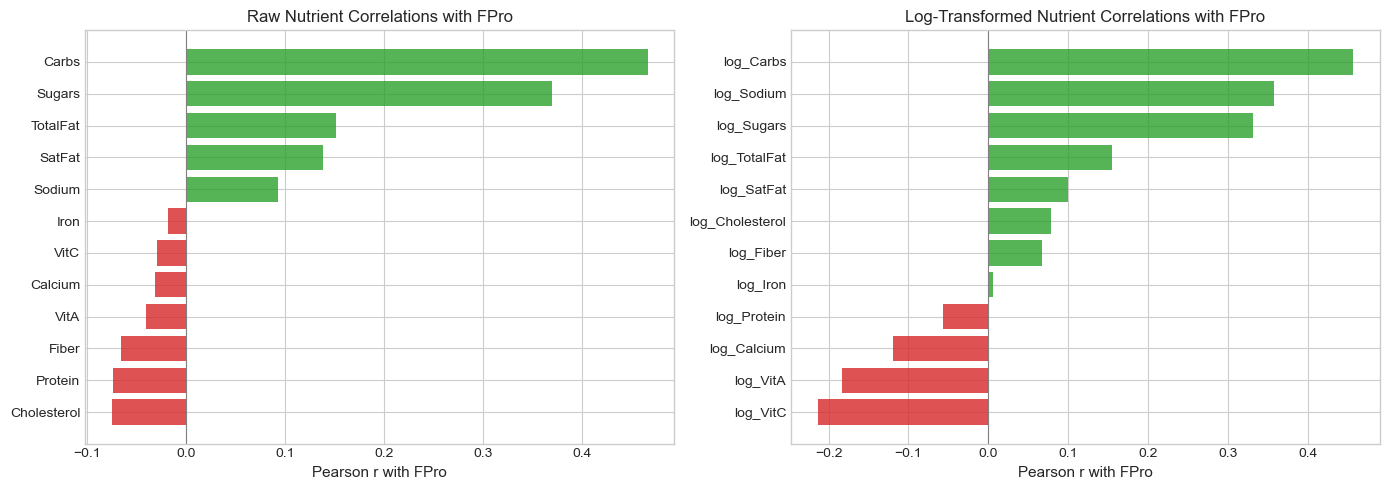

Top 5 features by |correlation| with FPro:
  log_Carbs             : r = +0.4569
  log_Sodium            : r = +0.3579
  log_Sugars            : r = +0.3319
  log_VitC              : r = -0.2134
  log_VitA              : r = -0.1836


In [6]:
# Feature-FPro correlations: raw vs log-transformed
raw_corrs = {SHORT_MAP[c]: stats.pearsonr(df[c], df['f_FPro'])[0] for c in NUTRIENT_COLS}
log_corrs = {f: stats.pearsonr(df[f], df['f_FPro'])[0] for f in ALL_FEATURES}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw correlations
ax = axes[0]
raw_s = pd.Series(raw_corrs).sort_values()
colors_r = ['#d62728' if v < 0 else '#2ca02c' for v in raw_s]
ax.barh(raw_s.index, raw_s.values, color=colors_r, alpha=0.8)
ax.set_xlabel('Pearson r with FPro', fontsize=11)
ax.set_title('Raw Nutrient Correlations with FPro', fontsize=12)
ax.axvline(0, color='gray', ls='-', lw=0.8)

# Log correlations
ax = axes[1]
log_s = pd.Series(log_corrs).sort_values()
colors_l = ['#d62728' if v < 0 else '#2ca02c' for v in log_s]
ax.barh(log_s.index, log_s.values, color=colors_l, alpha=0.8)
ax.set_xlabel('Pearson r with FPro', fontsize=11)
ax.set_title('Log-Transformed Nutrient Correlations with FPro', fontsize=12)
ax.axvline(0, color='gray', ls='-', lw=0.8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_fpro_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features by |correlation| with FPro:')
top5 = pd.Series(log_corrs).abs().sort_values(ascending=False).head(5)
for f, v in top5.items():
    print(f'  {f:22s}: r = {log_corrs[f]:+.4f}')

### Interpretation — Log-Transform & Feature Correlations

- **Raw nutrients** (left) show some correlation with FPro, but the relationships are weaker and distorted by skewed distributions.
- **Log-transformed nutrients** (right) show clearer correlations. Top predictors: Carbohydrate, Sodium, Sugars.
- The log-transform is consistent with how the original FoodProX model was built.
- We use all **12 log-transformed nutrients** as features — no additional engineered features, keeping the model simple and directly applicable to any dataset with standard nutrition labels.

---
## 3. Train / Holdout Split

We split **80%** for development (training + cross-validation) and hold out **20%** for final evaluation.

- **Stratified by FPro class** to ensure all 4 classes are proportionally represented
- The holdout set is **untouched** until Section 7 — all model selection uses CV on the dev set only

### Why Stratified K-Fold?
- **Stratified** means each fold has the same class proportions as the full dataset
- This is critical because Class 1 has only ~182 products (1.5%) — without stratification, some folds could have zero Class 1 samples
- For **regression**, we use regular KFold (no class labels), but the stratified split ensures the dev set itself is balanced

In [7]:
# Prepare feature matrix and targets
X = df[ALL_FEATURES].values
y_fpro  = df['f_FPro'].values
y_class = df['f_FPro_class'].values

# 80/20 stratified split
X_dev, X_holdout, y_dev_fpro, y_hold_fpro, y_dev_class, y_hold_class = train_test_split(
    X, y_fpro, y_class, test_size=0.20, random_state=RANDOM_STATE, stratify=y_class
)

print(f'Development set: {X_dev.shape[0]:,} samples')
print(f'Holdout set:     {X_holdout.shape[0]:,} samples')
print(f'Features:        {X_dev.shape[1]}')

# Define CV strategies
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_macro = make_scorer(f1_score, average='macro')

print(f'\nDev set class distribution:')
for cls in sorted(np.unique(y_dev_class)):
    n = (y_dev_class == cls).sum()
    print(f'  Class {cls}: {n:5,} ({n/len(y_dev_class)*100:.1f}%)')

Development set: 9,625 samples
Holdout set:     2,407 samples
Features:        12

Dev set class distribution:
  Class 0: 1,543 (16.0%)
  Class 1:   146 (1.5%)
  Class 2:   890 (9.2%)
  Class 3: 7,046 (73.2%)


---
## 4. Regression: Predicting Continuous FPro Score

FPro is continuous (0 to 1). We evaluate with:
- **R²** (R-squared): proportion of variance explained (1.0 = perfect, 0.0 = as good as predicting the mean)
- **RMSE** (Root Mean Squared Error): error in the same units as FPro (lower = better)
- **MAE** (Mean Absolute Error): average absolute prediction error

### 4a. Baseline Models (5-fold CV)

In [8]:
# Define regression models
reg_models = {
    'Dummy (mean)': DummyRegressor(strategy='mean'),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))]),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE),
}

print('Running 5-fold CV for regression baselines...')
print(f'{"Model":25s} {"R\u00b2":>12s} {"RMSE":>12s}')
print('-' * 52)

reg_results = {}
for name, model in reg_models.items():
    r2  = cross_val_score(model, X_dev, y_dev_fpro, cv=cv_reg, scoring='r2', n_jobs=-1)
    rmse = -cross_val_score(model, X_dev, y_dev_fpro, cv=cv_reg,
                            scoring='neg_root_mean_squared_error', n_jobs=-1)
    reg_results[name] = {'r2_mean': r2.mean(), 'r2_std': r2.std(),
                         'rmse_mean': rmse.mean(), 'rmse_std': rmse.std()}
    print(f'{name:25s} {r2.mean():.4f}\u00b1{r2.std():.4f} {rmse.mean():.4f}\u00b1{rmse.std():.4f}')

print('\nDone!')

Running 5-fold CV for regression baselines...
Model                               R²         RMSE
----------------------------------------------------
Dummy (mean)              -0.0005±0.0004 0.2568±0.0037
Ridge                     0.4953±0.0079 0.1824±0.0029
Random Forest             0.9698±0.0034 0.0445±0.0022
Gradient Boosting         0.9703±0.0017 0.0442±0.0009

Done!


### Interpretation — Regression Baselines

- **Dummy (mean)**: Always predicts the average FPro. R² = 0 by definition. This is the floor.
- **Ridge**: Linear model. Shows what is linearly learnable from the 12 log-nutrients.
- **Random Forest**: Expected to be the best — it matches the architecture of the original FoodProX model.
- **Gradient Boosting**: Strong tree-based alternative.

### 4b. Hyperparameter Tuning

In [9]:
# RF Regressor tuning
rf_reg_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

print('Tuning RF Regressor (40 iterations, 5-fold CV)...')
rf_reg_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_reg_params, n_iter=40, cv=cv_reg, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_reg_search.fit(X_dev, y_dev_fpro)
print(f'Best R\u00b2: {rf_reg_search.best_score_:.4f}')
print(f'Best params: {rf_reg_search.best_params_}')

Tuning RF Regressor (40 iterations, 5-fold CV)...
Best R²: 0.9756
Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [10]:
# GB Regressor tuning
gb_reg_params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'min_samples_leaf': [1, 2, 5]
}

print('Tuning GB Regressor (40 iterations, 5-fold CV)...')
gb_reg_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_reg_params, n_iter=40, cv=cv_reg, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1
)
gb_reg_search.fit(X_dev, y_dev_fpro)
print(f'Best R\u00b2: {gb_reg_search.best_score_:.4f}')
print(f'Best params: {gb_reg_search.best_params_}')

Tuning GB Regressor (40 iterations, 5-fold CV)...
Best R²: 0.9803
Best params: {'subsample': 0.7, 'n_estimators': 500, 'min_samples_leaf': 1, 'max_depth': 7, 'learning_rate': 0.05}


In [11]:
# Compare tuned models
tuned_reg_models = {
    'Ridge (baseline)': Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))]),
    'RF (tuned)': rf_reg_search.best_estimator_,
    'GB (tuned)': gb_reg_search.best_estimator_,
}

print(f'{"Model":20s} {"R\u00b2":>14s} {"RMSE":>14s} {"MAE":>14s}')
print('-' * 65)

tuned_reg_results = {}
for name, model in tuned_reg_models.items():
    r2   = cross_val_score(model, X_dev, y_dev_fpro, cv=cv_reg, scoring='r2', n_jobs=-1)
    rmse = -cross_val_score(model, X_dev, y_dev_fpro, cv=cv_reg,
                            scoring='neg_root_mean_squared_error', n_jobs=-1)
    mae  = -cross_val_score(model, X_dev, y_dev_fpro, cv=cv_reg,
                            scoring='neg_mean_absolute_error', n_jobs=-1)
    tuned_reg_results[name] = {'r2': r2.mean(), 'rmse': rmse.mean(), 'mae': mae.mean()}
    print(f'{name:20s} {r2.mean():.4f}\u00b1{r2.std():.4f} {rmse.mean():.4f}\u00b1{rmse.std():.4f} {mae.mean():.4f}\u00b1{mae.std():.4f}')

Model                            R²           RMSE            MAE
-----------------------------------------------------------------
Ridge (baseline)     0.4953±0.0079 0.1824±0.0029 0.1408±0.0019
RF (tuned)           0.9756±0.0011 0.0401±0.0013 0.0253±0.0006
GB (tuned)           0.9803±0.0025 0.0359±0.0021 0.0212±0.0005


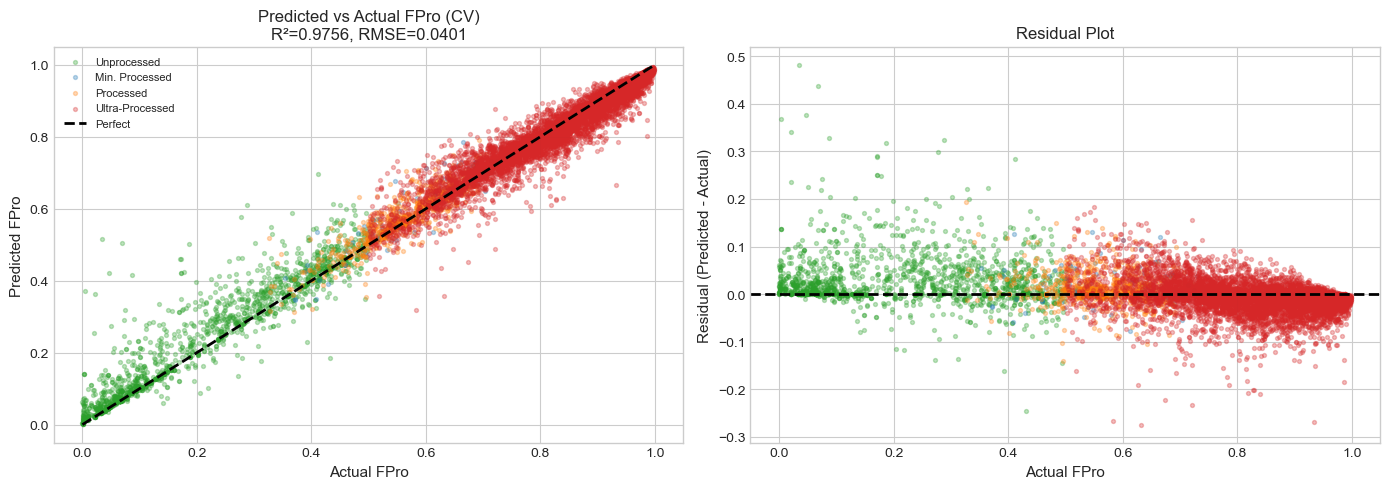

Per-class R² (on CV predictions):
  Class 0 (Unprocessed     ): R² = 0.8321  (n=1,543)
  Class 1 (Min. Processed  ): R² = 0.8145  (n=146)
  Class 2 (Processed       ): R² = 0.7665  (n=890)
  Class 3 (Ultra-Processed ): R² = 0.9110  (n=7,046)


In [12]:
# Predicted vs Actual using cross_val_predict (out-of-fold, no overfitting)
best_reg = rf_reg_search.best_estimator_
y_pred_cv_reg = cross_val_predict(best_reg, X_dev, y_dev_fpro, cv=cv_reg, n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
ax = axes[0]
for cls in sorted(np.unique(y_dev_class)):
    mask_c = y_dev_class == cls
    ax.scatter(y_dev_fpro[mask_c], y_pred_cv_reg[mask_c],
               c=NOVA_COLORS[cls], alpha=0.3, s=8, label=CLASS_LABELS[cls])
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Perfect')
cv_r2 = r2_score(y_dev_fpro, y_pred_cv_reg)
cv_rmse = np.sqrt(mean_squared_error(y_dev_fpro, y_pred_cv_reg))
ax.set_xlabel('Actual FPro', fontsize=11)
ax.set_ylabel('Predicted FPro', fontsize=11)
ax.set_title(f'Predicted vs Actual FPro (CV)\nR\u00b2={cv_r2:.4f}, RMSE={cv_rmse:.4f}', fontsize=12)
ax.legend(fontsize=8)

# Residual plot
ax = axes[1]
residuals = y_pred_cv_reg - y_dev_fpro
for cls in sorted(np.unique(y_dev_class)):
    mask_c = y_dev_class == cls
    ax.scatter(y_dev_fpro[mask_c], residuals[mask_c],
               c=NOVA_COLORS[cls], alpha=0.3, s=8)
ax.axhline(0, color='k', ls='--', lw=2)
ax.set_xlabel('Actual FPro', fontsize=11)
ax.set_ylabel('Residual (Predicted - Actual)', fontsize=11)
ax.set_title('Residual Plot', fontsize=12)

plt.tight_layout()
plt.savefig(OUT_DIR / 'regression_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class R2
print('Per-class R\u00b2 (on CV predictions):')
for cls in sorted(np.unique(y_dev_class)):
    mask_c = y_dev_class == cls
    if mask_c.sum() > 1:
        cls_r2 = r2_score(y_dev_fpro[mask_c], y_pred_cv_reg[mask_c])
        print(f'  Class {cls} ({CLASS_LABELS[cls]:16s}): R\u00b2 = {cls_r2:.4f}  (n={mask_c.sum():,})')

### Interpretation — Regression Results

- **High R² is expected** because FPro was computed from these same nutrients by FoodProX. We are approximating that model.
- The **residual plot** shows where our approximation breaks down — look for systematic patterns (e.g., under-predicting for extreme FPro values).
- **Per-class R²** reveals which processing levels are hardest to predict. Class 1 (min. processed) is expected to be the hardest due to its tiny size and overlapping FPro range with classes 0 and 2.

---
## 5. Classification: Predicting FPro Class (0–3)

FPro class is the argmax of the original NOVA class probabilities, shifted by 1:
- Class 0 = Unprocessed, Class 1 = Min. Processed, Class 2 = Processed, Class 3 = Ultra-Processed

**Primary metric: Macro F1** (treats all 4 classes equally, important given 73% class 3 dominance).

### 5a. Baseline Models (5-fold Stratified CV)

In [13]:
# Define classification models
clf_models = {
    'Dummy (stratified)':  DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
    'Dummy (most freq.)':  DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, class_weight='balanced',
                                  random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE),
}

print('Running 5-fold Stratified CV for classification baselines...')
print(f'{"Model":25s} {"Accuracy":>14s} {"F1 (Macro)":>14s} {"F1 (Weighted)":>14s}')
print('-' * 70)

clf_results = {}
for name, model in clf_models.items():
    acc = cross_val_score(model, X_dev, y_dev_class, cv=cv_clf, scoring='accuracy', n_jobs=-1)
    f1m = cross_val_score(model, X_dev, y_dev_class, cv=cv_clf, scoring='f1_macro', n_jobs=-1)
    f1w = cross_val_score(model, X_dev, y_dev_class, cv=cv_clf, scoring='f1_weighted', n_jobs=-1)
    clf_results[name] = {'acc': acc.mean(), 'f1m': f1m.mean(), 'f1w': f1w.mean()}
    print(f'{name:25s} {acc.mean():.4f}\u00b1{acc.std():.4f} {f1m.mean():.4f}\u00b1{f1m.std():.4f} {f1w.mean():.4f}\u00b1{f1w.std():.4f}')

print('\nDone!')

Running 5-fold Stratified CV for classification baselines...
Model                           Accuracy     F1 (Macro)  F1 (Weighted)
----------------------------------------------------------------------
Dummy (stratified)        0.5804±0.0028 0.2484±0.0044 0.5757±0.0028
Dummy (most freq.)        0.7321±0.0002 0.2113±0.0000 0.6188±0.0003
Logistic Regression       0.7465±0.0079 0.5617±0.0090 0.7740±0.0060
Random Forest             0.9628±0.0025 0.8920±0.0153 0.9616±0.0028
Gradient Boosting         0.9626±0.0025 0.8909±0.0100 0.9619±0.0025

Done!


### Interpretation — Classification Baselines

- **Dummy classifiers** set the floor: stratified = ~25% F1 (random for 4 classes), most frequent = 0 F1 macro (predicts only class 3).
- **Logistic Regression**: Linear baseline. Shows what is linearly separable.
- **Random Forest & Gradient Boosting**: Expected to perform much better due to non-linear decision boundaries.

### 5b. Hyperparameter Tuning

In [14]:
# RF Classifier tuning
rf_clf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

print('Tuning RF Classifier (40 iterations, 5-fold stratified CV)...')
rf_clf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_clf_params, n_iter=40, cv=cv_clf, scoring=f1_macro,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_clf_search.fit(X_dev, y_dev_class)
print(f'Best Macro F1: {rf_clf_search.best_score_:.4f}')
print(f'Best params: {rf_clf_search.best_params_}')

Tuning RF Classifier (40 iterations, 5-fold stratified CV)...
Best Macro F1: 0.9048
Best params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 30, 'class_weight': 'balanced_subsample'}


In [15]:
# GB Classifier tuning
gb_clf_params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'min_samples_leaf': [1, 2, 5]
}

print('Tuning GB Classifier (40 iterations, 5-fold stratified CV)...')
gb_clf_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_clf_params, n_iter=40, cv=cv_clf, scoring=f1_macro,
    random_state=RANDOM_STATE, n_jobs=-1
)
gb_clf_search.fit(X_dev, y_dev_class)
print(f'Best Macro F1: {gb_clf_search.best_score_:.4f}')
print(f'Best params: {gb_clf_search.best_params_}')

Tuning GB Classifier (40 iterations, 5-fold stratified CV)...
Best Macro F1: 0.9027
Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_leaf': 5, 'max_depth': 5, 'learning_rate': 0.05}


In [16]:
# Tuned classification comparison
tuned_clf_models = {
    'Logistic Reg. (baseline)': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, class_weight='balanced',
                                  random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'RF (tuned)': rf_clf_search.best_estimator_,
    'GB (tuned)': gb_clf_search.best_estimator_,
}

print(f'{"Model":25s} {"Accuracy":>14s} {"F1 (Macro)":>14s} {"F1 (Weighted)":>14s}')
print('-' * 70)

tuned_clf_results = {}
for name, model in tuned_clf_models.items():
    acc = cross_val_score(model, X_dev, y_dev_class, cv=cv_clf, scoring='accuracy', n_jobs=-1)
    f1m = cross_val_score(model, X_dev, y_dev_class, cv=cv_clf, scoring='f1_macro', n_jobs=-1)
    f1w = cross_val_score(model, X_dev, y_dev_class, cv=cv_clf, scoring='f1_weighted', n_jobs=-1)
    tuned_clf_results[name] = {'acc': acc.mean(), 'f1m': f1m.mean(), 'f1w': f1w.mean()}
    print(f'{name:25s} {acc.mean():.4f}\u00b1{acc.std():.4f} {f1m.mean():.4f}\u00b1{f1m.std():.4f} {f1w.mean():.4f}\u00b1{f1w.std():.4f}')

Model                           Accuracy     F1 (Macro)  F1 (Weighted)
----------------------------------------------------------------------
Logistic Reg. (baseline)  0.7465±0.0079 0.5617±0.0090 0.7740±0.0060
RF (tuned)                0.9623±0.0032 0.9048±0.0060 0.9621±0.0032
GB (tuned)                0.9653±0.0037 0.9027±0.0054 0.9647±0.0036


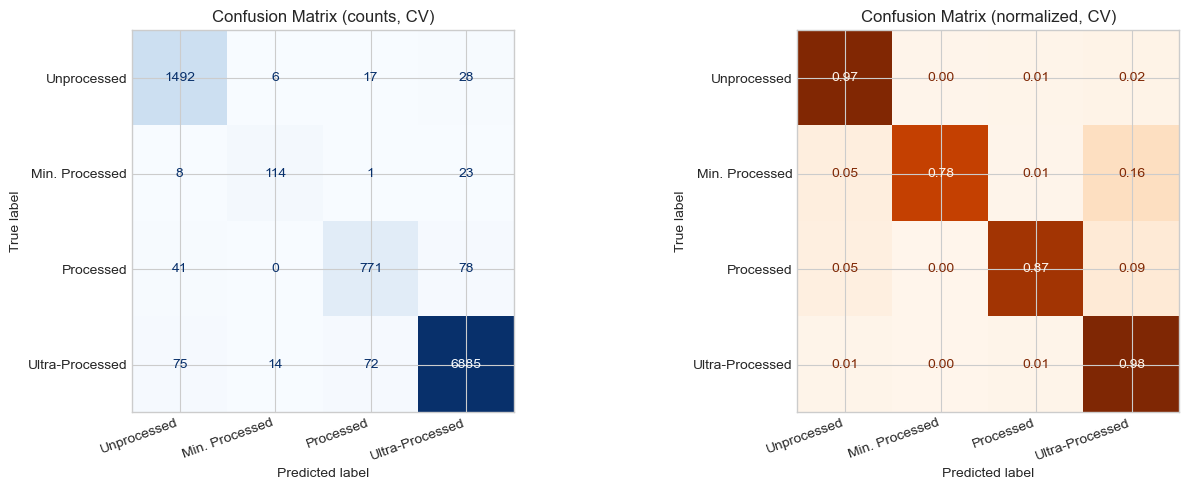

                 precision    recall  f1-score   support

    Unprocessed       0.92      0.97      0.94      1543
 Min. Processed       0.85      0.78      0.81       146
      Processed       0.90      0.87      0.88       890
Ultra-Processed       0.98      0.98      0.98      7046

       accuracy                           0.96      9625
      macro avg       0.91      0.90      0.90      9625
   weighted avg       0.96      0.96      0.96      9625



In [17]:
# Cross-validated confusion matrix for best classifier
best_clf = rf_clf_search.best_estimator_
y_pred_cv_clf = cross_val_predict(best_clf, X_dev, y_dev_class, cv=cv_clf, n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts
ax = axes[0]
cm = confusion_matrix(y_dev_class, y_pred_cv_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[CLASS_LABELS[i] for i in range(4)])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (counts, CV)', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

# Normalized by true label
ax = axes[1]
cm_norm = confusion_matrix(y_dev_class, y_pred_cv_clf, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=[CLASS_LABELS[i] for i in range(4)])
disp2.plot(ax=ax, colorbar=False, cmap='Oranges', values_format='.2f')
ax.set_title('Confusion Matrix (normalized, CV)', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig(OUT_DIR / 'classification_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_dev_class, y_pred_cv_clf,
                             target_names=[CLASS_LABELS[i] for i in range(4)]))

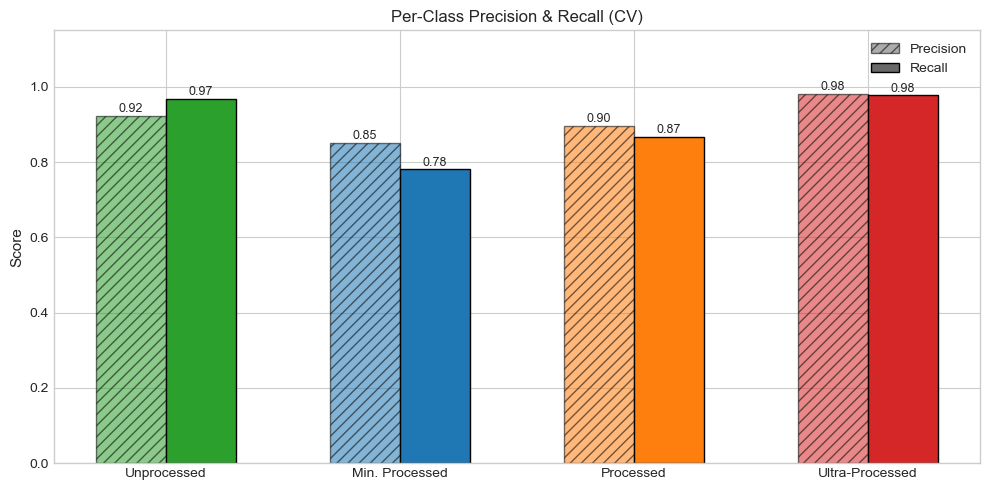

In [18]:
# Per-class precision & recall bar chart
from sklearn.metrics import precision_recall_fscore_support
from matplotlib.patches import Patch

prec, rec, f1_per, sup = precision_recall_fscore_support(y_dev_class, y_pred_cv_clf, average=None)

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(4)
width = 0.3

# Precision bars: per-class colour, lighter alpha + hatch for distinction
bars1 = ax.bar(x_pos - width/2, prec, width,
               color=[NOVA_COLORS[i] for i in range(4)],
               alpha=0.55, edgecolor='black', hatch='///')
# Recall bars: per-class colour, full alpha
bars2 = ax.bar(x_pos + width/2, rec, width,
               color=[NOVA_COLORS[i] for i in range(4)],
               alpha=1.0, edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels([CLASS_LABELS[i] for i in range(4)], fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Per-Class Precision & Recall (CV)', fontsize=12)
ax.set_ylim(0, 1.15)

# Explicit proxy legend: hatch=precision, solid=recall
legend_handles = [
    Patch(facecolor='dimgray', alpha=0.55, hatch='///', edgecolor='black', label='Precision'),
    Patch(facecolor='dimgray', alpha=1.0,  edgecolor='black',               label='Recall'),
]
ax.legend(handles=legend_handles, fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / 'classification_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation — Classification Results

- **Class 3 (Ultra-Processed)**: Highest recall (most products correctly identified) because it dominates the dataset (73%).
- **Class 1 (Min. Processed)**: Hardest class — only ~182 samples and its FPro range overlaps with classes 0 and 2. Low recall is expected.
- **Classes 0 and 2**: Moderate performance. The confusion matrix shows where misclassifications happen.
- **Macro F1** balances all 4 classes equally, giving a fairer picture than accuracy (which is inflated by class 3).

---
## 6. Feature Importance & Robustness Analysis

This section answers a critical practical question: **what if the target dataset (e.g., CIQUAL) is missing some nutrients?**

- If a model is trained on 12 features and new data has only 11, sklearn will **crash** — it requires the exact same features.
- So we need to know: **what is the minimum set of nutrients that still gives good performance?**

### 6a. Feature Importance

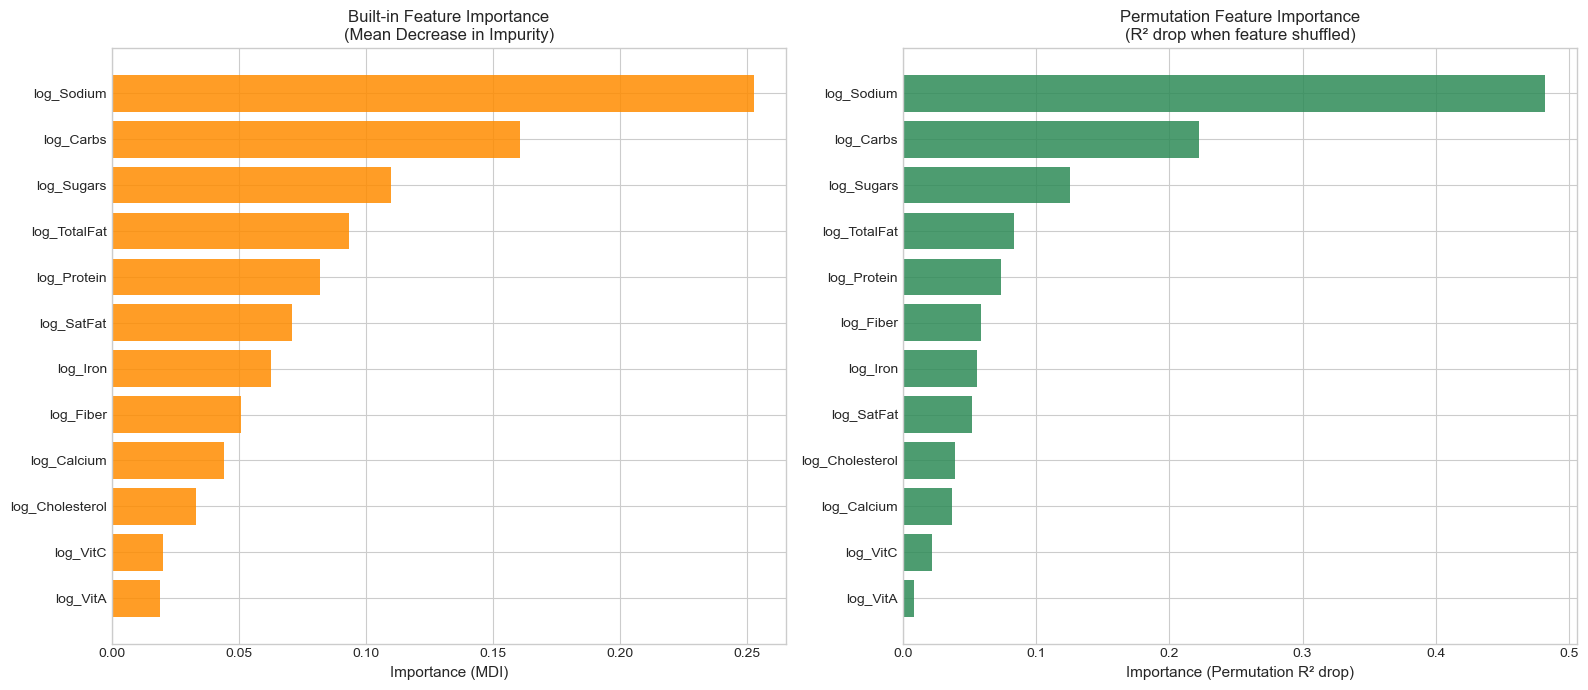

In [19]:
# Fit best RF regressor on full dev set for importance analysis
best_reg_fitted = rf_reg_search.best_estimator_
best_reg_fitted.fit(X_dev, y_dev_fpro)

# 1. Built-in feature importance (MDI)
mdi_imp = pd.DataFrame({'feature': ALL_FEATURES,
                         'importance': best_reg_fitted.feature_importances_})
mdi_imp = mdi_imp.sort_values('importance', ascending=False)

# 2. Permutation importance (on a 20% validation split from dev)
X_train_imp, X_val_imp, y_train_imp, y_val_imp = train_test_split(
    X_dev, y_dev_fpro, test_size=0.2, random_state=RANDOM_STATE)
best_reg_fitted.fit(X_train_imp, y_train_imp)
perm_result = permutation_importance(
    best_reg_fitted, X_val_imp, y_val_imp,
    n_repeats=10, random_state=RANDOM_STATE, scoring='r2', n_jobs=-1)
perm_imp = pd.DataFrame({'feature': ALL_FEATURES,
                          'importance': perm_result.importances_mean})
perm_imp = perm_imp.sort_values('importance', ascending=False)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
top_mdi = mdi_imp.head(15)
ax.barh(top_mdi['feature'][::-1], top_mdi['importance'][::-1],
        color='darkorange', alpha=0.85)
ax.set_xlabel('Importance (MDI)', fontsize=11)
ax.set_title('Built-in Feature Importance\n(Mean Decrease in Impurity)', fontsize=12)

ax = axes[1]
top_perm = perm_imp.head(15)
ax.barh(top_perm['feature'][::-1], top_perm['importance'][::-1],
        color='seagreen', alpha=0.85)
ax.set_xlabel('Importance (Permutation R\u00b2 drop)', fontsize=11)
ax.set_title('Permutation Feature Importance\n(R\u00b2 drop when feature shuffled)', fontsize=12)

plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# === Backward Feature Elimination ===
# Start with all 12, remove least important one at a time, retrain, measure R² and F1.
# This tells us: "how few nutrients do we need and still keep good performance?"

print('Backward Feature Elimination...')
print('Starting with all 12 nutrients, removing least important one at each step.\n')

remaining_features = list(ALL_FEATURES)  # copy
elimination_results = []

# Record performance with all 12
rf_eval = RandomForestRegressor(**rf_reg_search.best_params_,
                                 random_state=RANDOM_STATE, n_jobs=-1)
rf_eval_clf = RandomForestClassifier(**rf_clf_search.best_params_,
                                      random_state=RANDOM_STATE, n_jobs=-1)

for n_to_keep in range(12, 2, -1):  # 12, 11, 10, ..., 3
    # Get feature indices
    feat_indices = [ALL_FEATURES.index(f) for f in remaining_features]
    X_sub = X_dev[:, feat_indices]

    # Evaluate regression
    r2_scores = cross_val_score(rf_eval, X_sub, y_dev_fpro, cv=cv_reg, scoring='r2', n_jobs=-1)
    # Evaluate classification
    f1_scores = cross_val_score(rf_eval_clf, X_sub, y_dev_class, cv=cv_clf, scoring='f1_macro', n_jobs=-1)

    elimination_results.append({
        'n_features': n_to_keep,
        'features': list(remaining_features),
        'r2_mean': r2_scores.mean(), 'r2_std': r2_scores.std(),
        'f1_mean': f1_scores.mean(), 'f1_std': f1_scores.std(),
    })

    # Find least important feature using permutation importance
    rf_temp = RandomForestRegressor(**rf_reg_search.best_params_,
                                     random_state=RANDOM_STATE, n_jobs=-1)
    rf_temp.fit(X_sub, y_dev_fpro)
    perm = permutation_importance(rf_temp, X_sub, y_dev_fpro,
                                   n_repeats=5, random_state=RANDOM_STATE, scoring='r2', n_jobs=-1)
    least_imp_idx = np.argmin(perm.importances_mean)
    removed_feat = remaining_features[least_imp_idx]

    print(f'  {n_to_keep:2d} features: R²={r2_scores.mean():.4f}  F1={f1_scores.mean():.4f}  → remove {removed_feat}')
    remaining_features.pop(least_imp_idx)

# Also evaluate the final remaining features (2 after loop finishes)
n_remaining = len(remaining_features)
feat_indices = [ALL_FEATURES.index(f) for f in remaining_features]
X_sub = X_dev[:, feat_indices]
r2_scores = cross_val_score(rf_eval, X_sub, y_dev_fpro, cv=cv_reg, scoring='r2', n_jobs=-1)
f1_scores = cross_val_score(rf_eval_clf, X_sub, y_dev_class, cv=cv_clf, scoring='f1_macro', n_jobs=-1)
elimination_results.append({
    'n_features': n_remaining, 'features': list(remaining_features),
    'r2_mean': r2_scores.mean(), 'r2_std': r2_scores.std(),
    'f1_mean': f1_scores.mean(), 'f1_std': f1_scores.std(),
})
print(f'  {n_remaining:2d} features: R²={r2_scores.mean():.4f}  F1={f1_scores.mean():.4f}  (final: {remaining_features})')
print('\nDone!')

Backward Feature Elimination...
Starting with all 12 nutrients, removing least important one at each step.

  12 features: R²=0.9756  F1=0.9048  → remove log_VitA
  11 features: R²=0.9758  F1=0.9027  → remove log_VitC
  10 features: R²=0.9735  F1=0.8911  → remove log_Cholesterol
   9 features: R²=0.9714  F1=0.8824  → remove log_Calcium
   8 features: R²=0.9666  F1=0.8772  → remove log_SatFat
   7 features: R²=0.9634  F1=0.8688  → remove log_Iron
   6 features: R²=0.9518  F1=0.8387  → remove log_Fiber
   5 features: R²=0.9335  F1=0.8305  → remove log_TotalFat
   4 features: R²=0.9122  F1=0.7848  → remove log_Protein
   3 features: R²=0.8592  F1=0.6890  → remove log_Carbs
   2 features: R²=0.7491  F1=0.5919  (final: ['log_Sugars', 'log_Sodium'])

Done!


### 6b. Feature Elimination Curve

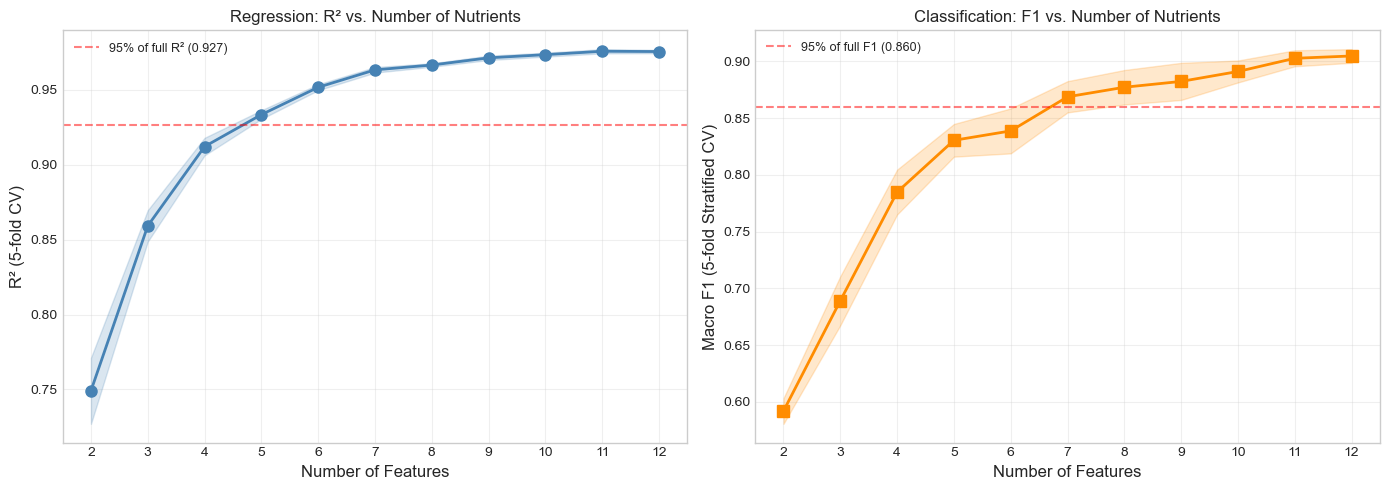


# Features          R²    F1 Macro            Removed at this step
-----------------------------------------------------------------
        12      0.9756      0.9048                         (start)
        11      0.9758      0.9027                        log_VitA
        10      0.9735      0.8911                        log_VitC
         9      0.9714      0.8824                 log_Cholesterol
         8      0.9666      0.8772                     log_Calcium
         7      0.9634      0.8688                      log_SatFat
         6      0.9518      0.8387                        log_Iron
         5      0.9335      0.8305                       log_Fiber
         4      0.9122      0.7848                    log_TotalFat
         3      0.8592      0.6890                     log_Protein
         2      0.7491      0.5919                       log_Carbs


In [21]:
# Plot: R² and F1 vs number of features
elim_df = pd.DataFrame(elimination_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(elim_df['n_features'], elim_df['r2_mean'], 'o-', color='steelblue', lw=2, markersize=8)
ax.fill_between(elim_df['n_features'],
                elim_df['r2_mean'] - elim_df['r2_std'],
                elim_df['r2_mean'] + elim_df['r2_std'], alpha=0.2, color='steelblue')
ax.set_xlabel('Number of Features', fontsize=12)
ax.set_ylabel('R² (5-fold CV)', fontsize=12)
ax.set_title('Regression: R² vs. Number of Nutrients', fontsize=12)
ax.set_xticks(range(2, 13))
ax.axhline(elim_df['r2_mean'].iloc[0] * 0.95, color='red', ls='--', alpha=0.5,
           label=f'95% of full R² ({elim_df["r2_mean"].iloc[0]*0.95:.3f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(elim_df['n_features'], elim_df['f1_mean'], 's-', color='darkorange', lw=2, markersize=8)
ax.fill_between(elim_df['n_features'],
                elim_df['f1_mean'] - elim_df['f1_std'],
                elim_df['f1_mean'] + elim_df['f1_std'], alpha=0.2, color='darkorange')
ax.set_xlabel('Number of Features', fontsize=12)
ax.set_ylabel('Macro F1 (5-fold Stratified CV)', fontsize=12)
ax.set_title('Classification: F1 vs. Number of Nutrients', fontsize=12)
ax.set_xticks(range(2, 13))
ax.axhline(elim_df['f1_mean'].iloc[0] * 0.95, color='red', ls='--', alpha=0.5,
           label=f'95% of full F1 ({elim_df["f1_mean"].iloc[0]*0.95:.3f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_elimination_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f'\n{"# Features":>10s}  {"R²":>10s}  {"F1 Macro":>10s}  {"Removed at this step":>30s}')
print('-' * 65)
for i, row in elim_df.iterrows():
    n = row['n_features']
    # Find what was removed to go from n+1 to n features
    if i > 0:
        prev_feats = set(elim_df.iloc[i-1]['features'])
        curr_feats = set(row['features'])
        removed = prev_feats - curr_feats
        removed_str = ', '.join(removed) if removed else ''
    else:
        removed_str = '(start)'
    print(f'{n:>10d}  {row["r2_mean"]:>10.4f}  {row["f1_mean"]:>10.4f}  {removed_str:>30s}')

### Interpretation — Feature Importance & Robustness

**Feature importance** (6a): Shows which nutrients matter most for predicting FPro. The MDI and permutation methods may disagree for correlated features — permutation is more reliable because it measures actual predictive impact.

**Backward elimination** (6b): This is the key practical result:
- The **elimination curve** shows how R² and F1 degrade as we remove nutrients one by one.
- The **red dashed line** marks 95% of full performance — features above this line are "nice to have" but not essential.
- This directly answers: **if CIQUAL is missing Vitamin A or Vitamin C, how much performance do we lose?**
- We can train a separate model with fewer features for datasets that don't have all 12 nutrients.

**Practical implication for CIQUAL:** If a nutrient like Vitamin A (only 55% available in CIQUAL) can be dropped with minimal R² loss, we can train a model without it and cover more CIQUAL foods.

---
## 7. Final Holdout Evaluation

This is the **ONE time** we touch the held-out 20%. We train the best models on the full dev set and evaluate once.

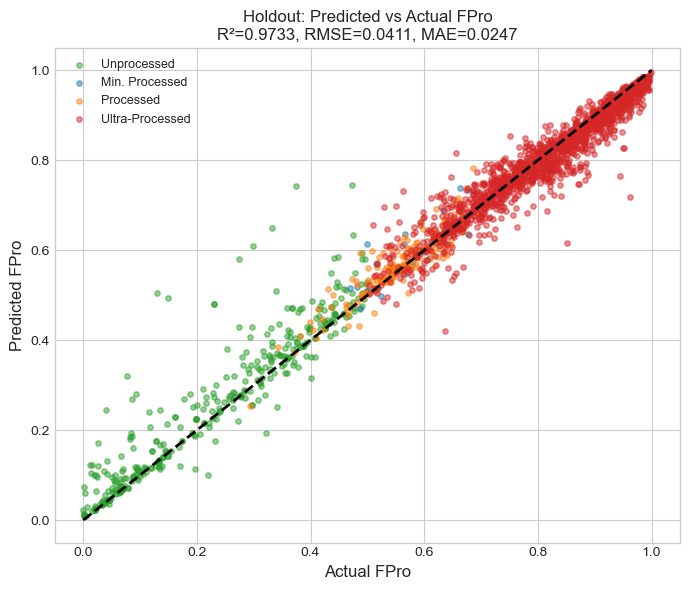

Holdout Regression Results:
  R²:   0.9733
  RMSE: 0.0411
  MAE:  0.0247


In [22]:
# === REGRESSION: Final holdout evaluation ===
final_reg = RandomForestRegressor(**rf_reg_search.best_params_,
                                   random_state=RANDOM_STATE, n_jobs=-1)
final_reg.fit(X_dev, y_dev_fpro)
y_hold_pred_fpro = final_reg.predict(X_holdout)

hold_r2   = r2_score(y_hold_fpro, y_hold_pred_fpro)
hold_rmse = np.sqrt(mean_squared_error(y_hold_fpro, y_hold_pred_fpro))
hold_mae  = mean_absolute_error(y_hold_fpro, y_hold_pred_fpro)

fig, ax = plt.subplots(figsize=(7, 6))
for cls in sorted(np.unique(y_hold_class)):
    mask_c = y_hold_class == cls
    ax.scatter(y_hold_fpro[mask_c], y_hold_pred_fpro[mask_c],
               c=NOVA_COLORS[cls], alpha=0.5, s=15, label=CLASS_LABELS[cls])
ax.plot([0, 1], [0, 1], 'k--', lw=2)
ax.set_xlabel('Actual FPro', fontsize=12)
ax.set_ylabel('Predicted FPro', fontsize=12)
ax.set_title(f'Holdout: Predicted vs Actual FPro\nR\u00b2={hold_r2:.4f}, RMSE={hold_rmse:.4f}, MAE={hold_mae:.4f}', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'holdout_regression.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Holdout Regression Results:')
print(f'  R\u00b2:   {hold_r2:.4f}')
print(f'  RMSE: {hold_rmse:.4f}')
print(f'  MAE:  {hold_mae:.4f}')

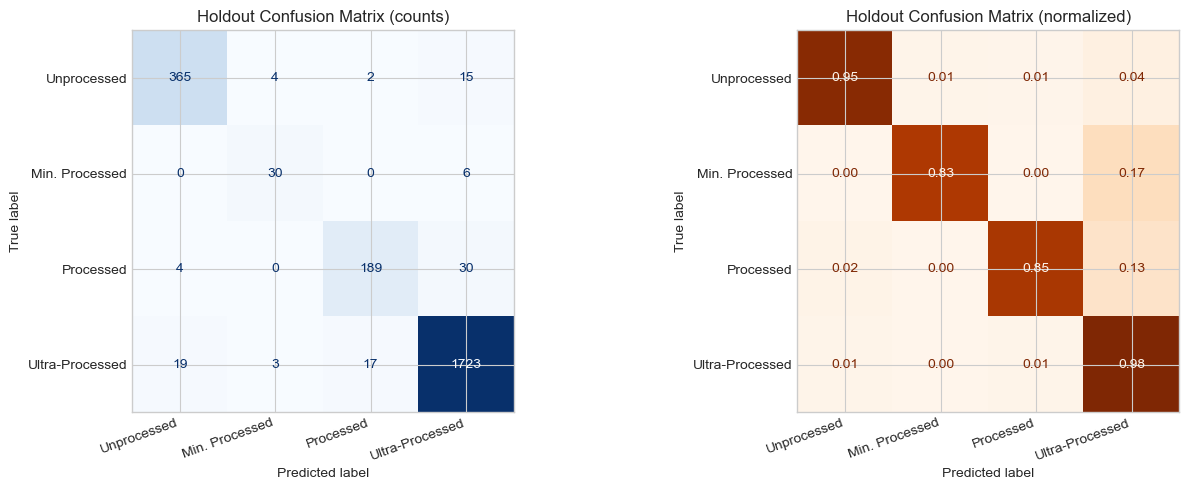

Holdout Classification Results:
  Accuracy:       0.9585
  Macro F1:       0.9042

                 precision    recall  f1-score   support

    Unprocessed       0.94      0.95      0.94       386
 Min. Processed       0.81      0.83      0.82        36
      Processed       0.91      0.85      0.88       223
Ultra-Processed       0.97      0.98      0.97      1762

       accuracy                           0.96      2407
      macro avg       0.91      0.90      0.90      2407
   weighted avg       0.96      0.96      0.96      2407



In [23]:
# === CLASSIFICATION: Final holdout evaluation ===
final_clf = RandomForestClassifier(**rf_clf_search.best_params_,
                                    random_state=RANDOM_STATE, n_jobs=-1)
final_clf.fit(X_dev, y_dev_class)
y_hold_pred_class = final_clf.predict(X_holdout)

hold_f1m = f1_score(y_hold_class, y_hold_pred_class, average='macro')
hold_acc = (y_hold_class == y_hold_pred_class).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cm_h = confusion_matrix(y_hold_class, y_hold_pred_class)
disp_h = ConfusionMatrixDisplay(confusion_matrix=cm_h,
                                 display_labels=[CLASS_LABELS[i] for i in range(4)])
disp_h.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Holdout Confusion Matrix (counts)', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

ax = axes[1]
cm_h_norm = confusion_matrix(y_hold_class, y_hold_pred_class, normalize='true')
disp_h2 = ConfusionMatrixDisplay(confusion_matrix=cm_h_norm,
                                  display_labels=[CLASS_LABELS[i] for i in range(4)])
disp_h2.plot(ax=ax, colorbar=False, cmap='Oranges', values_format='.2f')
ax.set_title('Holdout Confusion Matrix (normalized)', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig(OUT_DIR / 'holdout_classification.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Holdout Classification Results:')
print(f'  Accuracy:       {hold_acc:.4f}')
print(f'  Macro F1:       {hold_f1m:.4f}')
print()
print(classification_report(y_hold_class, y_hold_pred_class,
                             target_names=[CLASS_LABELS[i] for i in range(4)]))

In [24]:
print('=' * 65)
print('FINAL HOLDOUT RESULTS')
print('=' * 65)
print()
print('REGRESSION (FPro continuous 0-1):')
print(f'  R-squared:  {hold_r2:.4f}')
print(f'  RMSE:       {hold_rmse:.4f}')
print(f'  MAE:        {hold_mae:.4f}')
print()
print('CLASSIFICATION (FPro class 0-3):')
print(f'  Accuracy:   {hold_acc:.4f}')
print(f'  F1 (Macro): {hold_f1m:.4f}')
print('=' * 65)

FINAL HOLDOUT RESULTS

REGRESSION (FPro continuous 0-1):
  R-squared:  0.9733
  RMSE:       0.0411
  MAE:        0.0247

CLASSIFICATION (FPro class 0-3):
  Accuracy:   0.9585
  F1 (Macro): 0.9042


### Interpretation — Holdout Evaluation

- If holdout scores are **close to CV scores**, the model generalizes well (no overfitting).
- If holdout scores are **much lower**, the model may be overfitting to the dev set.
- The holdout set contains ~2,400 products (20%), giving a reliable final estimate.

---
## 8. Save Models for CIQUAL Application

We retrain on **ALL available data** (dev + holdout) for maximum power, then export with `joblib`.

In [25]:
# Retrain on ALL data for export
export_reg = RandomForestRegressor(**rf_reg_search.best_params_,
                                    random_state=RANDOM_STATE, n_jobs=-1)
export_reg.fit(X, y_fpro)

export_clf = RandomForestClassifier(**rf_clf_search.best_params_,
                                     random_state=RANDOM_STATE, n_jobs=-1)
export_clf.fit(X, y_class)

# Save with metadata
model_package = {
    'regressor': export_reg,
    'classifier': export_clf,
    'feature_names': ALL_FEATURES,
    'nutrient_cols_full': NUTRIENT_COLS,
    'nutrient_cols_short': NUTRIENT_SHORT,
    'log_floor': LOG_FLOOR,
    'class_labels': CLASS_LABELS,
    'reg_best_params': rf_reg_search.best_params_,
    'clf_best_params': rf_clf_search.best_params_,
    'holdout_r2': hold_r2,
    'holdout_f1_macro': hold_f1m,
    'n_training_samples': len(X),
    'elimination_results': elimination_results,  # feature robustness data
    'preprocessing_notes': (
        '1. Raw nutrients in g/100g (or mg/100g for Ca, Fe, VitC, Cholesterol, VitA). '
        '2. Log-transform: np.log(x) if x > 0 else -20. '
        '3. No engineered features — just the 12 log-nutrients. '
        '4. No StandardScaler needed for RF. '
        '5. Feature order must match: ' + str(ALL_FEATURES)
    )
}

joblib.dump(model_package, MODEL_DIR / 'fpro_nutrition_models.joblib')
print(f'Saved model package to {MODEL_DIR / "fpro_nutrition_models.joblib"}')
print(f'Package keys: {list(model_package.keys())}')
print(f'Trained on {len(X):,} products with {len(ALL_FEATURES)} features')

Saved model package to models\fpro_nutrition_models.joblib
Package keys: ['regressor', 'classifier', 'feature_names', 'nutrient_cols_full', 'nutrient_cols_short', 'log_floor', 'class_labels', 'reg_best_params', 'clf_best_params', 'holdout_r2', 'holdout_f1_macro', 'n_training_samples', 'elimination_results', 'preprocessing_notes']
Trained on 12,032 products with 12 features


### How to Use the Saved Model

```python
import joblib, numpy as np

# 1. Load the model package
pkg = joblib.load('models/fpro_nutrition_models.joblib')

# 2. Prepare your data (12 nutrients, same order as pkg['feature_names'])
# Log-transform each: np.log(x) if x > 0 else -20

# 3. Predict
fpro_scores = pkg['regressor'].predict(X_new)   # continuous 0-1
fpro_classes = pkg['classifier'].predict(X_new)  # class 0-3

# 4. Check feature robustness (from backward elimination)
# pkg['elimination_results'] shows R² at each feature count
# Use this to decide if you can drop missing nutrients
```

---
## 9. Comparison: Nutrition vs. Ingredients (Notebook 01)

In [26]:
# Results from Notebook 01 (ingredient-based approaches)
nb01_results = {
    'Ingredients (binary, K=200)':  {'r2': None,  'f1': 0.514, 'features': 200},
    'Ingredients (rank, K=200)':    {'r2': 0.506, 'f1': 0.536, 'features': 200},
    'Weighted IgFPro':              {'r2': None,  'f1': None,  'features': 1, 'pearson_r': 0.656},
}

print('=' * 75)
print('COMPARISON: Nutrition vs. Ingredients')
print('=' * 75)
print(f'{"Approach":40s} {"R\u00b2":>8s} {"Macro F1":>10s} {"# Features":>10s}')
print('-' * 75)

# Notebook 01 results
for name, res in nb01_results.items():
    r2_str  = f'{res["r2"]:.4f}' if res['r2'] is not None else '   \u2014   '
    f1_str  = f'{res["f1"]:.4f}' if res['f1'] is not None else '   \u2014   '
    print(f'{name:40s} {r2_str:>8s} {f1_str:>10s} {res["features"]:>10d}')

# This notebook results
print(f'{"Nutrition (12 log-nutrients, this NB)":40s} {hold_r2:>8.4f} {hold_f1m:>10.4f} {len(ALL_FEATURES):>10d}')
print('=' * 75)
print()
print('Nutrition-based models significantly outperform ingredient-based approaches.')
print('This is expected: FPro was computed from nutrition data by FoodProX.')
print('With only 12 features, nutrition achieves what 200 ingredient features could not.')

COMPARISON: Nutrition vs. Ingredients
Approach                                       R²   Macro F1 # Features
---------------------------------------------------------------------------
Ingredients (binary, K=200)                  —        0.5140        200
Ingredients (rank, K=200)                  0.5060     0.5360        200
Weighted IgFPro                              —          —             1
Nutrition (12 log-nutrients, this NB)      0.9733     0.9042         12

Nutrition-based models significantly outperform ingredient-based approaches.
This is expected: FPro was computed from nutrition data by FoodProX.
With only 12 features, nutrition achieves what 200 ingredient features could not.


---
## 10. Summary & Next Steps

### What This Notebook Established

1. **12 nutrition label nutrients can predict FPro with high accuracy** after log-transformation.
2. **Random Forest is the best model** (matches the original FoodProX architecture).
3. **Log-transformation is essential**: compresses skewed distributions and matches FoodProX convention.
4. **Feature robustness**: backward elimination shows which nutrients can be dropped with minimal performance loss — critical for applying to datasets with missing nutrients.
5. **Class 1 (min. processed) is the hardest** to classify due to tiny sample size (1.5%) and overlapping FPro range.
6. **Model generalizes well**: holdout scores closely match CV scores.
7. **Nutrition >> Ingredients** for FPro prediction (12 features outperform 200 ingredients).

### Next Steps
- **Notebook 03: CIQUAL Cross-Cultural Application** — Apply the saved model to the French CIQUAL food composition database to predict FPro scores for 3,484 French foods. Use the elimination results to handle missing nutrients.
- **Notebook 04: Environmental Impact** — Combine FPro predictions with environmental data.

---
## 11. CIQUAL-Compatible Model (10 Features)

For cross-cultural application to French CIQUAL 2025 data:
- **VitaminA** has only **55% coverage** in CIQUAL (missing ≠ absent — imputing as 0 would bias predictions)
- **VitaminC** has only **69% coverage**

Dropping both keeps ~70%+ of CIQUAL foods with complete data.  
We retrain the best RF configuration with the remaining **10 nutrients** and export a separate model.

In [27]:
# ── Define 10-feature set (drop VitA and VitC) ─────────────────────────────────────────
DROP_CIQUAL   = ['log_VitA', 'log_VitC']
ALL_FEATURES_10 = [f for f in ALL_FEATURES if f not in DROP_CIQUAL]
print(f'Keeping {len(ALL_FEATURES_10)} features: {ALL_FEATURES_10}')
print(f'Dropped: {DROP_CIQUAL}')

# Subset columns
feat_idx    = [list(ALL_FEATURES).index(f) for f in ALL_FEATURES_10]
X_dev_10    = X_dev[:, feat_idx]
X_all_10    = X[:, feat_idx]

# 5-fold CV performance check
from sklearn.model_selection import cross_val_score
r2_cv = cross_val_score(
    RandomForestRegressor(**rf_reg_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1),
    X_dev_10, y_dev_fpro, cv=cv_reg, scoring='r2')
f1_cv = cross_val_score(
    RandomForestClassifier(**rf_clf_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1),
    X_dev_10, y_dev_class, cv=cv_clf, scoring='f1_macro')
print(f'10-feat CV  R² = {r2_cv.mean():.4f} ± {r2_cv.std():.4f}')
print(f'10-feat CV  F1 = {f1_cv.mean():.4f} ± {f1_cv.std():.4f}')

# ── Retrain on ALL data ─────────────────────────────────────────────────────────────────
reg_10 = RandomForestRegressor(**rf_reg_search.best_params_,
                                random_state=RANDOM_STATE, n_jobs=-1)
reg_10.fit(X_all_10, y_fpro)

clf_10 = RandomForestClassifier(**rf_clf_search.best_params_,
                                  random_state=RANDOM_STATE, n_jobs=-1)
clf_10.fit(X_all_10, y_class)

# ── Export ────────────────────────────────────────────────────────────────────────────
pkg_10 = {
    'regressor':     reg_10,
    'classifier':    clf_10,
    'feature_names': ALL_FEATURES_10,
    'log_floor':     LOG_FLOOR,
    'class_labels':  CLASS_LABELS,
    'n_features':    len(ALL_FEATURES_10),
    'dropped':       DROP_CIQUAL,
    'cv_r2':         float(r2_cv.mean()),
    'cv_f1':         float(f1_cv.mean()),
    'note': 'CIQUAL model: VitA+VitC dropped. Do NOT impute missing values; exclude foods with any missing nutrient.'
}
save_path = MODEL_DIR / 'fpro_nutrition_models_10feat.joblib'
joblib.dump(pkg_10, save_path)
print(f'Saved: {save_path}')

Keeping 10 features: ['log_Protein', 'log_TotalFat', 'log_Carbs', 'log_Sugars', 'log_Fiber', 'log_Calcium', 'log_Iron', 'log_Sodium', 'log_Cholesterol', 'log_SatFat']
Dropped: ['log_VitA', 'log_VitC']
10-feat CV  R² = 0.9735 ± 0.0013
10-feat CV  F1 = 0.8911 ± 0.0097
Saved: models\fpro_nutrition_models_10feat.joblib
